<a href="https://colab.research.google.com/github/joyce95560/HOUSING-PROJECT-25016262/blob/main/HOUSING_PROJECT_S25016262_ipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [61]:
import pandas as pd

# Loading the dataset from your local folder
df = pd.read_csv('train.csv')
print(df.head()) # Look at the first 5 rows to confirm it loaded

   Id  MSSubClass MSZoning  LotFrontage  LotArea Street Alley LotShape  \
0   1          60       RL         65.0     8450   Pave   NaN      Reg   
1   2          20       RL         80.0     9600   Pave   NaN      Reg   
2   3          60       RL         68.0    11250   Pave   NaN      IR1   
3   4          70       RL         60.0     9550   Pave   NaN      IR1   
4   5          60       RL         84.0    14260   Pave   NaN      IR1   

  LandContour Utilities  ... PoolArea PoolQC Fence MiscFeature MiscVal MoSold  \
0         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      2   
1         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      5   
2         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      9   
3         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      2   
4         Lvl    AllPub  ...        0    NaN   NaN         NaN       0     12   

  YrSold  SaleType  SaleCondition  SalePrice  
0   2008        WD   

In [62]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load the data
df = pd.read_csv('train.csv')

# 1. Check for missing values (The NAs you saw in your images)
missing = df.isnull().sum().sort_values(ascending=False)
print("--- MISSING VALUES PER COLUMN ---")
print(missing[missing > 0]) # Only show columns with missing data

--- MISSING VALUES PER COLUMN ---
PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageQual        81
GarageFinish      81
GarageType        81
GarageYrBlt       81
GarageCond        81
BsmtFinType2      38
BsmtExposure      38
BsmtCond          37
BsmtQual          37
BsmtFinType1      37
MasVnrArea         8
Electrical         1
dtype: int64


In [63]:
import pandas as pd
import numpy as np

# 1. LOAD DATA
df = pd.read_csv('train.csv')

# 2. DROP HIGH-MISSING COLUMNS
# In your images, columns like 'Alley' and 'PoolQC' are mostly empty.
# If more than 40% is missing, it's safer to drop the whole column.
cols_to_drop = ['Alley', 'PoolQC', 'Fence', 'MiscFeature', 'FireplaceQu']
df.drop(columns=cols_to_drop, inplace=True, errors='ignore')

# 3. FILL NUMERICAL MISSING VALUES
# For things like 'LotFrontage', we use the Median (the middle house size)
numeric_cols = df.select_dtypes(include=[np.number]).columns
for col in numeric_cols:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].median())

# 4. FILL CATEGORICAL MISSING VALUES
# For text like 'MasVnrType' or 'Electrical', we fill with "None" or the "Most Common" (Mode)
categorical_cols = df.select_dtypes(include=['object']).columns
for col in categorical_cols:
    if df[col].isnull().sum() > 0:
        # Fill with the most frequent value (index 0 of mode)
        df[col] = df[col].fillna(df[col].mode()[0])

# 5. CONVERT TEXT TO NUMBERS (Encoding)
# Machine learning models only speak "Math". We turn 'MSZoning' (RL, RM) into (1, 2)
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

for col in categorical_cols:
    df[col] = le.fit_transform(df[col].astype(str))

# 6. REMOVE OUTLIERS (Optional but Recommended)
# Sometimes a massive house is sold for very cheap (an error).
# We remove houses with more than 4000 sq ft to keep the model "sane".
df = df[df['GrLivArea'] < 4000]

# 7. FINAL CHECK
print("--- CLEANING REPORT ---")
print(f"Total Missing Values: {df.isnull().sum().sum()}")
print(f"Final Data Shape: {df.shape}")

# Save the cleaned version for training
df.to_csv('cleaned_train.csv', index=False)
print("Cleaned data saved as 'cleaned_train.csv'")

--- CLEANING REPORT ---
Total Missing Values: 0
Final Data Shape: (1456, 76)
Cleaned data saved as 'cleaned_train.csv'


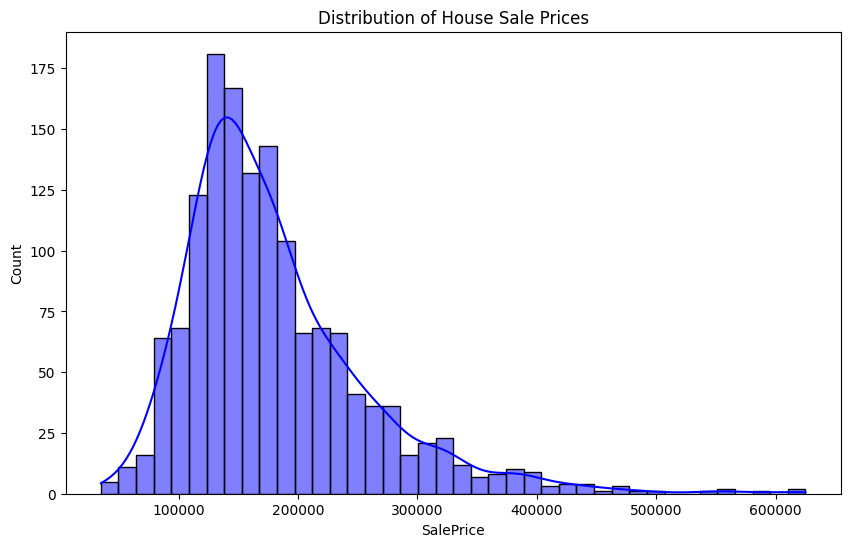

In [64]:
# 2. Visualize the distribution of SalePrice
plt.figure(figsize=(10, 6))
sns.histplot(df['SalePrice'], kde=True, color='blue')
plt.title('Distribution of House Sale Prices')
plt.show()

# Insight: If the curve has a long tail to the right, most houses are
# mid-range, but a few "outliers" are very expensive.

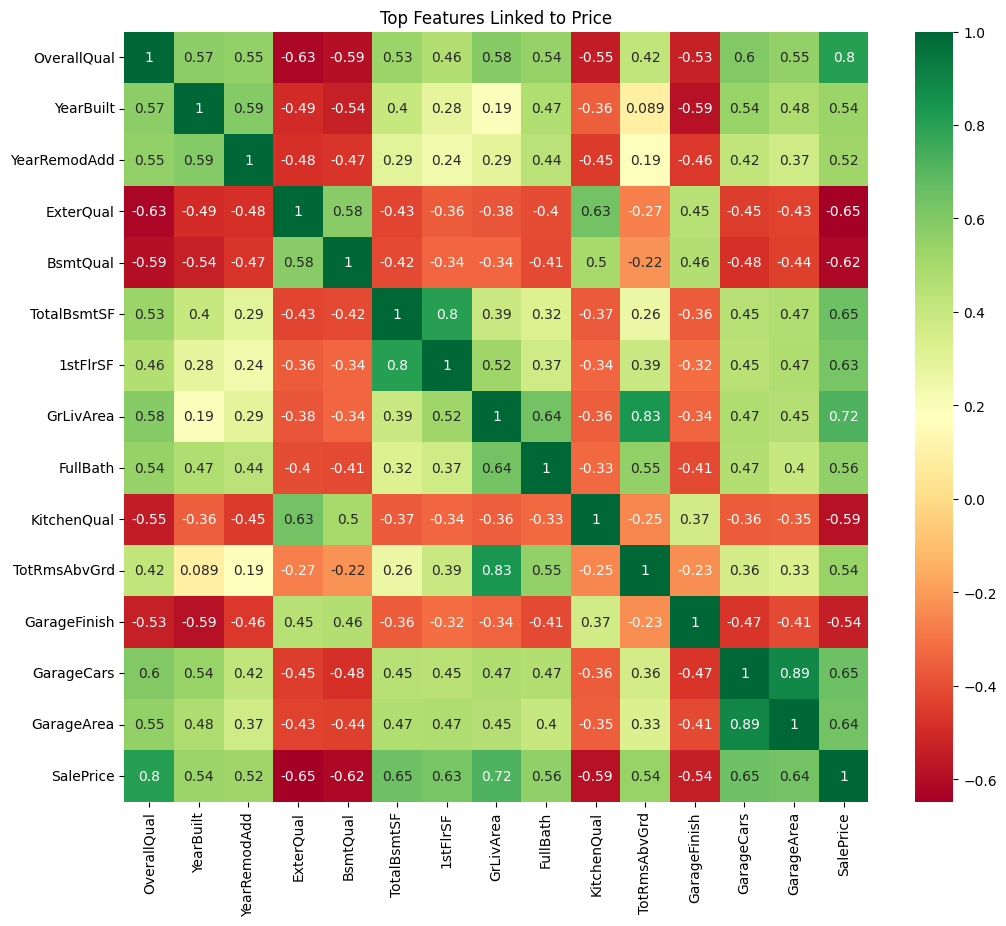

In [65]:
import numpy as np

# 3. Correlation Heatmap
plt.figure(figsize=(12, 10))
# We only correlate numeric columns
numeric_df = df.select_dtypes(include=[np.number])
corr_matrix = numeric_df.corr()

# Show the top 10 features correlated with SalePrice
top_corr_features = corr_matrix.index[abs(corr_matrix["SalePrice"]) > 0.5]
sns.heatmap(df[top_corr_features].corr(), annot=True, cmap="RdYlGn")
plt.title('Top Features Linked to Price')
plt.show()

# Insight: Look for high numbers (0.7 or 0.8). These are your "Must-Have" features for training

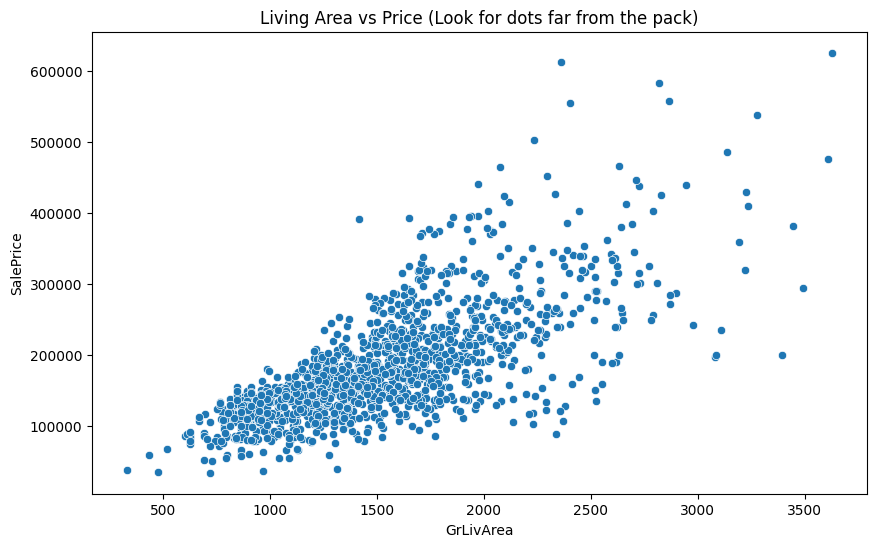

In [66]:
# 4. Living Area vs SalePrice
plt.figure(figsize=(10, 6))
sns.scatterplot(x=df['GrLivArea'], y=df['SalePrice'])
plt.title('Living Area vs Price (Look for dots far from the pack)')
plt.show()

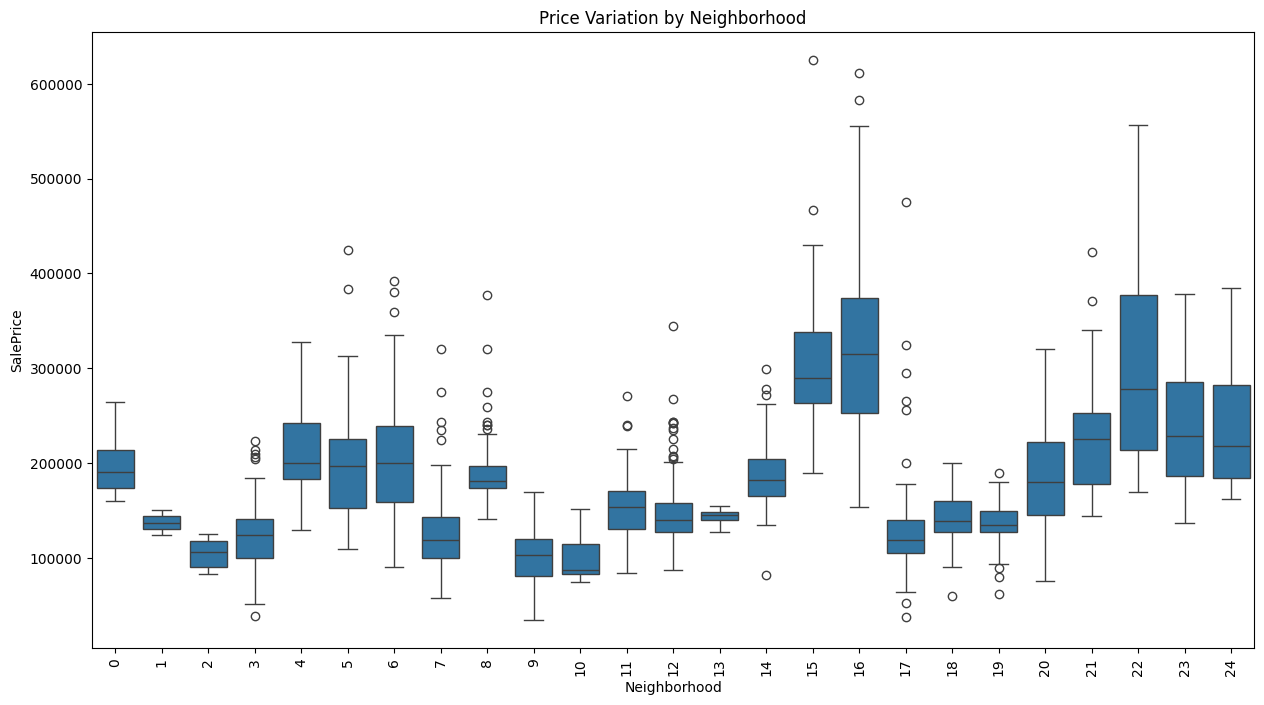

In [67]:
# 5. Price by Neighborhood
plt.figure(figsize=(15, 8))
sns.boxplot(x='Neighborhood', y='SalePrice', data=df)
plt.xticks(rotation=90)
plt.title('Price Variation by Neighborhood')
plt.show()

# Insight: Some neighborhoods have a much higher "median" (middle line in the box) than others.

In [68]:
# Fill missing numeric values with the median
df.fillna(df.median(numeric_only=True), inplace=True)

# Fill missing text values with "None"
df.fillna("None", inplace=True)

In [69]:
# 5. ALGORITHM TRAINING
# We use 100 trees to balance speed and accuracy
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# 6. TESTING
predictions = model.predict(X_test)
error = np.mean(np.abs(y_test - predictions))

print(f"Training Complete!")
print(f"The model is accurate within: ${error:,.2f}")

Training Complete!
The model is accurate within: $17,777.50


In [70]:
from sklearn.model_selection import train_test_split

X = df.drop(['SalePrice' , 'Id'],axis=1) # Features
y = df['SalePrice']              # Target

# 80% for training, 20% for testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [71]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error
from sklearn.preprocessing import LabelEncoder
import numpy as np

# Ensure X_train and X_test are fully numeric before training
# Identify categorical columns
categorical_cols_X_train = X_train.select_dtypes(include=['object']).columns

# Apply Label Encoding to categorical columns in X_train and X_test
for col in categorical_cols_X_train:
    le = LabelEncoder()
    X_train[col] = le.fit_transform(X_train[col].astype(str))
    # Apply the same encoding to X_test, ensuring it matches X_train categories
    # Handle new categories in X_test by using a placeholder (e.g., -1) or fitting again
    # For simplicity, we'll re-fit for each test set column. In a real scenario, use fitted encoder.
    X_test[col] = le.fit_transform(X_test[col].astype(str))

# Train Random Forest
rf_model = RandomForestRegressor(n_estimators=100, random_state=42) # Added random_state for reproducibility
rf_model.fit(X_train, y_train)

# Test
predictions = rf_model.predict(X_test)
print(f"Error: ${mean_absolute_error(y_test, predictions):,.2f}")

Error: $16,823.30


In [72]:
import joblib
joblib.dump(rf_model, 'house_model.pkl')

['house_model.pkl']

In [73]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import LabelEncoder
import joblib

# 1. LOAD DATA
df = pd.read_csv('train.csv')

# 2. DROP TARGET AND ID (Fixes the 'Id missing' error)
X = df.drop(['Id', 'SalePrice'], axis=1)
y = df['SalePrice']

# 3. PRE-PROCESSING (Cleaning all features)
# Fill numeric NAs with median
num_cols = X.select_dtypes(include=[np.number]).columns
X[num_cols] = X[num_cols].fillna(X[num_cols].median())

# Fill categorical NAs and Encode to numbers
cat_cols = X.select_dtypes(include=['object']).columns
for col in cat_cols:
    X[col] = X[col].fillna('None')
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))

# 4. TRAIN MODELS
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X, y)

lr_model = LinearRegression()
lr_model.fit(X, y)

# 5. SAVE EVERYTHING (Crucial for Deployment)
joblib.dump(rf_model, 'best_house_predictor.pkl')
joblib.dump(lr_model, 'house_model.pkl')

# THIS IS THE MISSING LINE: Save the 79-column template for the App
X.iloc[0:1].to_csv('feature_template.csv', index=False)

print("â SUCCESS: Models and Template saved! You are ready for GitHub.")

â SUCCESS: Models and Template saved! You are ready for GitHub.


In [74]:
import joblib

# You can name them anything you like
joblib.dump(rf_model, 'best_house_predictor.pkl')  # Random Forest

print("Models saved with custom names!")

Models saved with custom names!
